In [1]:
from limited_data_experiment import (
    score_oracle,
    do_experiment,
    load_experiments_data_spe,
)
import numpy as np
from itertools import count
import multiprocessing as mp
from functools import partial

# ALL_RUNS = [30, 31, 32, 33, 34]
ALL_RUNS = [100, 101, 102, 103, 104]

/home/porepy/porepy/src/porepy/numerics/nonlinear/nonlinear_solvers.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange  # type: ignore


In [ ]:
cv_results, scoring = score_oracle(load_experiments_data_spe, ALL_RUNS, n_jobs=-1)

for score in scoring:
    print(score)
    print("Train scores:", cv_results[f"train_{score}"])
    print("Test scores:", cv_results[f"test_{score}"])
    print("Mean Train:", np.mean(cv_results[f"train_{score}"]))
    print("Mean Test:", np.mean(cv_results[f"test_{score}"]))
    print()

Scoring oracle


0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0

mae_success
Train scores: [-0.11563307 -0.11773203 -0.11872395 -0.1186961  -0.11775388]
Test scores: [-0.11690049 -0.12060234 -0.11940595 -0.12234269 -0.12295639]
Mean Train: -0.1177078064601238
Mean Test: -0.1204415706094718

r2_success
Train scores: [0.95692887 0.95287379 0.95144098 0.95031597 0.95234191]
Test scores: [0.94793442 0.95167646 0.95163928 0.95203535 0.94147949]
Mean Train: 0.9527803043740143
Mean Test: 0.9489530007129586

acc_failure
Train scores: [0.9936438  0.9936438  0.99358087 0.9940847  0.99295199]
Test scores: [0.99144224 0.98741505 0.99169393 0.99446123 0.99118832]
Mean Train: 0.99358103163389
Mean Test: 0.991240153513558

f1_failure
Train scores: [0.99126222 0.99123644 0.99114891 0.99195619 0.99022005]
Test scores: [0.98815331 0.98281787 0.98866369 0.99204052 0.98823529]
Mean Train: 0.9911647609702362
Mean Test: 0.9879821368151722



WARNING! There are options you set that were not used!
WARNING! could be spelling mistake, etc!
There is one unused database option. It is:
Option left: name:--f=/home/porepy/.local/share/jupyter/runtime/kernel-v3d205a582502e91e658b840a872b214a27271942e.json (no value) source: command line
WARNING! There are options you set that were not used!
WARNING! could be spelling mistake, etc!
There is one unused database option. It is:
Option left: name:--f=/home/porepy/.local/share/jupyter/runtime/kernel-v3d205a582502e91e658b840a872b214a27271942e.json (no value) source: command line
WARNING! There are options you set that were not used!
WARNING! could be spelling mistake, etc!
There is one unused database option. It is:
Option left: name:--f=/home/porepy/.local/share/jupyter/runtime/kernel-v3d205a582502e91e658b840a872b214a27271942e.json (no value) source: command line
WARNING! There are options you set that were not used!
WARNING! could be spelling mistake, etc!
There is one unused database op

In [ ]:
from limited_data_experiment import (
    do_experiment,
    load_experiments_data_spe,
)
from itertools import count
import multiprocessing as mp
from functools import partial

GAMMA_VALS = [
    0.05,
    0.1,
    0.5,
    1,
]
EPS_VALS = [
    0,
    0.1,
    0.5,
    0.9,
]

experiment_setups = []


for seq_id in ALL_RUNS:
    for gamma in GAMMA_VALS:
        for eps in EPS_VALS:
            experiment_setups.append(
                {
                    "incremental_learning": True,
                    "one_decision": False,
                    "seq_id": seq_id,
                    "gamma": gamma,
                    "eps": eps,
                    "batch_size": 128,
                }
            )

    for one_decision in [False, True]:
        experiment_setups.append(
            {
                "incremental_learning": False,
                "one_decision": one_decision,
                "seq_id": seq_id,
                "gamma": 1,
                "eps": 0,
                "batch_size": 128,
            }
        )

cnt = count()
for experiment in experiment_setups:
    experiment["experiment_idx"] = next(cnt)
    experiment["experiments_total"] = len(experiment_setups)

num_processes = mp.cpu_count()
print(f"{num_processes = }")
with mp.Pool(num_processes) as pool:
    results = pool.map(partial(do_experiment, load_experiments_data=partial(load_experiments_data_spe, dir="../stats/"), all_run_ids=ALL_RUNS), experiment_setups)


# results = [do_experiment(x, load_experiments_data=partial(load_experiments_data_spe, dir="../stats/")) for x in experiment_setups]

num_processes = 16
Start experiment 28 / 90
Start experiment 6 / 90Start experiment 24 / 90

Start experiment 0 / 90
Start experiment 16 / 90
Start experiment 14 / 90Start experiment 26 / 90

Start experiment 18 / 90
Start experiment 22 / 90
Start experiment 10 / 90
Start experiment 8 / 90
Start experiment 4 / 90
Start experiment 12 / 90
Start experiment 30 / 90Start experiment 20 / 90

Start experiment 2 / 90
Done experiment 0 / 90
Done experiment 18 / 90
Done experiment 6 / 90
Done experiment 24 / 90
Done experiment 8 / 90
Done experiment 10 / 90
Done experiment 28 / 90
Done experiment 4 / 90
Done experiment 2 / 90
Done experiment 16 / 90
Done experiment 20 / 90
Start experiment 1 / 90
Done experiment 26 / 90
Done experiment 30 / 90
Done experiment 22 / 90
Done experiment 12 / 90
Start experiment 7 / 90
Start experiment 25 / 90
Start experiment 19 / 90
Start experiment 9 / 90
Start experiment 11 / 90
Done experiment 14 / 90
Start experiment 29 / 90
Start experiment 5 / 90
Start exper

WARNING! There are options you set that were not used!
WARNING! could be spelling mistake, etc!
There is one unused database option. It is:
Option left: name:--f=/home/porepy/.local/share/jupyter/runtime/kernel-v3d205a582502e91e658b840a872b214a27271942e.json (no value) source: command line
WARNING! There are options you set that were not used!
WARNING! could be spelling mistake, etc!
There is one unused database option. It is:
Option left: name:--f=/home/porepy/.local/share/jupyter/runtime/kernel-v3d205a582502e91e658b840a872b214a27271942e.json (no value) source: command line
WARNING! There are options you set that were not used!
WARNING! could be spelling mistake, etc!
There is one unused database option. It is:
Option left: name:--f=/home/porepy/.local/share/jupyter/runtime/kernel-v3d205a582502e91e658b840a872b214a27271942e.json (no value) source: command line
WARNING! There are options you set that were not used!
WARNING! could be spelling mistake, etc!
There is one unused database op

In [8]:
results = [do_experiment(x, load_experiments_data=partial(load_experiments_data_spe, dir="../stats/"), all_run_ids=ALL_RUNS) for x in experiment_setups]

Start experiment 0 / 90


KeyboardInterrupt: 

In [4]:
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib

matplotlib.rcdefaults()

# tex_fonts = {
#     # Use LaTeX to write all text
#     # "text.usetex": True,
#     "font.family": "serif",
#     "axes.labelsize": 10,
#     "font.size": 10,
#     # Make the legend/label fonts a little smaller
#     "legend.fontsize": 9,
#     "xtick.labelsize": 9,
#     "ytick.labelsize": 9,
# }

# sns.set_theme(
#     # context="talk",
#     context="paper",
#     # rc={"figure.figsize": (8, 6)},
#     # palette="colorblind6",
#     style="whitegrid",
#     rc=tex_fonts,
# )

In [5]:
from collections import defaultdict
import numpy as np
import pandas as pd


data_for_pandas = defaultdict(lambda: [])
for result in results:
    data_for_pandas["incremental_learning"].append(result["incremental_learning"])
    data_for_pandas["one_decision"].append(result["one_decision"])
    data_for_pandas["seq_id"].append(result["seq_id"])
    data_for_pandas["gamma"].append(result["gamma"])
    data_for_pandas["eps"].append(result["eps"])
    data_for_pandas["batch_size"].append(result["batch_size"])
    data_for_pandas["NTS"].append((result["NTS"]))
    data_for_pandas["TopEPS"].append((result["TopEPS"]))
    data_for_pandas["mean_NTS"].append(np.mean(result["NTS"]))
    data_for_pandas["mean_TopEPS"].append(np.mean(result["TopEPS"]))
    data_for_pandas['ypred'].append(result['ypred'])
    data_for_pandas['yoracle'].append(result['yoracle'])
    data_for_pandas['yfeedback'].append(result['yfeedback'])
    data_for_pandas['tpred'].append(result['tpred'])
    data_for_pandas['tfeedback'].append(result['tfeedback'])
    data_for_pandas['decision_id'].append(result['decision_id'])


df = pd.DataFrame(data_for_pandas)
df.head(1)

/home/porepy/.local/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/porepy/.local/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,incremental_learning,one_decision,seq_id,gamma,eps,batch_size,NTS,TopEPS,mean_NTS,mean_TopEPS,ypred,yoracle,yfeedback,tpred,tfeedback,decision_id
0,True,False,100,0.05,0.0,128,[],[],NaN,NaN,[],[],[],[],[],[]


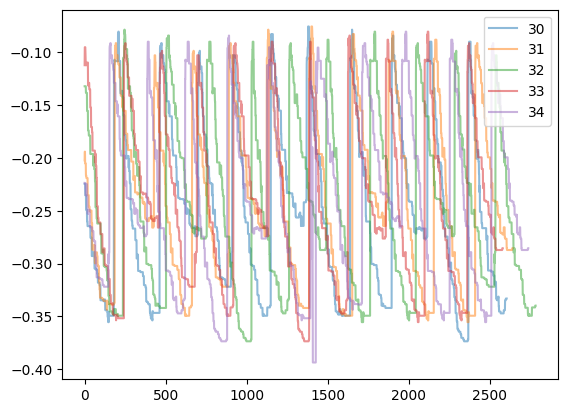

In [7]:
from matplotlib import pyplot as plt

for row in df[(df.eps == 0) & (df.gamma == 1) & (df.incremental_learning) & ~df.one_decision].itertuples(index=False):
    plt.plot((row.yoracle), label=row.seq_id, alpha=0.5)
plt.legend()


In [8]:
df_heatmap = df[(df.incremental_learning) & ~(df.one_decision)]
# df_heatmap = df_heatmap.groupby(["eps", 'gamma'])["mean_TopEPS"].agg(["mean", 'std']).unstack()
df_heatmap = df_heatmap.groupby(["eps", 'gamma'])["mean_NTS"].agg(["mean", 'std']).unstack()

df_heatmap

mean                                     std                      \
gamma      0.05      0.10      0.50      1.00      0.05      0.10      0.50   
eps                                                                           
0.0    0.946208  0.966713  0.984855  0.983630  0.028677  0.013252  0.009372   
0.1    0.949317  0.963565  0.972700  0.972392  0.025489  0.010594  0.008321   
0.5    0.935616  0.954417  0.969278  0.971518  0.027165  0.014269  0.007212   
0.9    0.938723  0.958899  0.964000  0.965518  0.023874  0.011376  0.007118   

                 
gamma      1.00  
eps              
0.0    0.008198  
0.1    0.007708  
0.5    0.008312  
0.9    0.008532

In [9]:
annot = df_heatmap['mean'].round(2).astype(str) + "±" + df_heatmap['std'].round(2).astype(str)
annot

gamma,0.05,0.10,0.50,1.00
eps,,,,
0.0,0.95±0.03,0.97±0.01,0.98±0.01,0.98±0.01
0.1,0.95±0.03,0.96±0.01,0.97±0.01,0.97±0.01
0.5,0.94±0.03,0.95±0.01,0.97±0.01,0.97±0.01
0.9,0.94±0.02,0.96±0.01,0.96±0.01,0.97±0.01


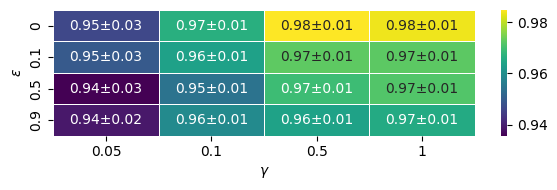

In [10]:
plt.figure(figsize=(6, 2))
sns.heatmap(
    np.array(df_heatmap["mean"]),
    # np.array(df_heatmap["std"]),
    annot=np.array(annot),
    cmap="viridis",
    linecolor="white",
    linewidths=0.5,
    yticklabels=EPS_VALS,
    xticklabels=GAMMA_VALS,
    fmt="",
)
plt.ylabel(r"$\varepsilon$")
plt.xlabel(r"$\gamma$")
# plt.title(r"Top-$\varepsilon$ Acc.", fontweight="bold")
plt.tight_layout()
# plt.savefig("scenarioA_topeps.pdf")

In [11]:
from sklearn.neural_network import MLPRegressor

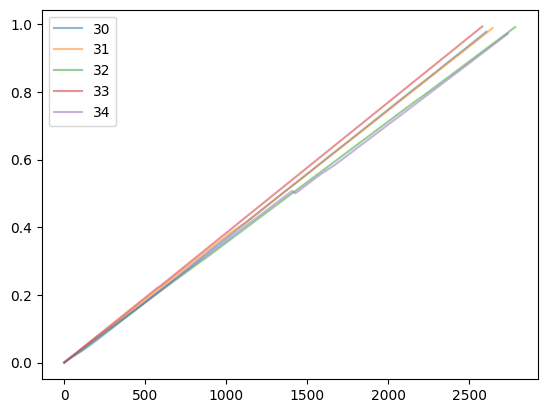

In [12]:
from matplotlib import pyplot as plt

for row in df[(df.eps == 0.) & (df.gamma == 0.5) & (df.incremental_learning) & ~df.one_decision].itertuples(index=False):
    # plt.plot((row.NTS), label=row.seq_id, alpha=0.5)

    # plt.plot(np.cumsum(row.TopEPS) / np.size(row.TopEPS), label=row.seq_id, alpha=0.5)
    plt.plot(np.cumsum(row.NTS) / np.size(row.NTS), label=row.seq_id, alpha=0.5)

plt.legend()


In [13]:
df_special = df[~df.incremental_learning]
df_special = df_special.groupby('one_decision')[['mean_NTS']].agg(["mean", 'std'])
df_special

mean_NTS          
                  mean       std
one_decision                    
False         0.970096  0.016978
True          0.988056  0.006187

In [14]:
df_special['mean_NTS']

,mean,std
one_decision,,
False,0.970096,0.016978
True,0.988056,0.006187


/tmp/ipykernel_1145545/3740096419.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


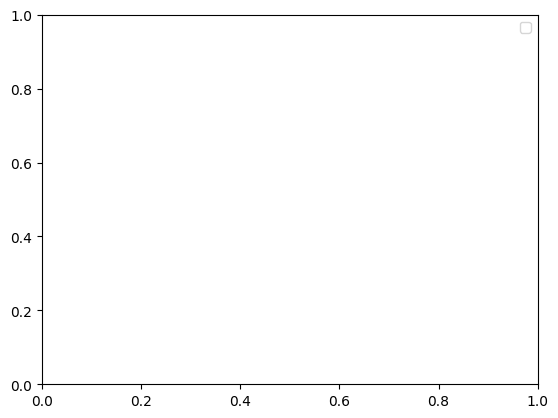

In [15]:
from matplotlib import pyplot as plt

for row in df[(df.eps == 0.5) & (df.seq_id == 'R34') & (df.incremental_learning) & ~df.one_decision].itertuples(index=False):
    plt.plot(np.cumsum(row.TopEPS) / np.size(row.TopEPS), label=row.gamma, alpha=0.5)
    # plt.plot(np.cumsum(row.NTS) / np.size(row.NTS), label=row.gamma, alpha=0.5)

plt.legend()

Text(0, 0.5, 'ML overhead, s')

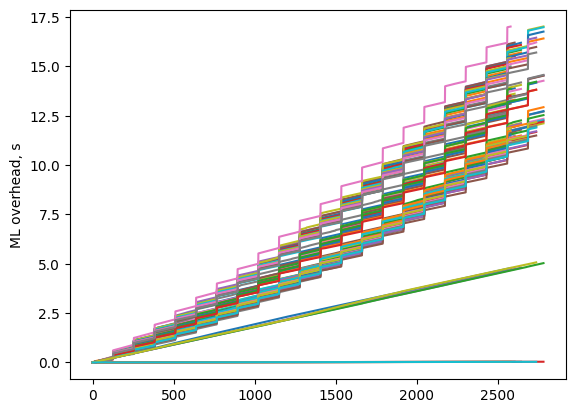

In [16]:
for row in df.itertuples(index=False):
    plt.plot(np.cumsum(row.tfeedback + row.tpred))

plt.ylabel('ML overhead, s')

In [17]:
row.__dir__()

['__doc__',
 '__slots__',
 '_fields',
 '_field_defaults',
 '__new__',
 '_make',
 '_replace',
 '__repr__',
 '_asdict',
 '__getnewargs__',
 '__match_args__',
 'incremental_learning',
 'one_decision',
 'seq_id',
 'gamma',
 'eps',
 'batch_size',
 'NTS',
 'TopEPS',
 'mean_NTS',
 'mean_TopEPS',
 'ypred',
 'yoracle',
 'yfeedback',
 'tpred',
 'tfeedback',
 'decision_id',
 '__module__',
 '__hash__',
 '__getattribute__',
 '__lt__',
 '__le__',
 '__eq__',
 '__ne__',
 '__gt__',
 '__ge__',
 '__iter__',
 '__len__',
 '__getitem__',
 '__add__',
 '__mul__',
 '__rmul__',
 '__contains__',
 'index',
 'count',
 '__class_getitem__',
 '__str__',
 '__setattr__',
 '__delattr__',
 '__init__',
 '__reduce_ex__',
 '__reduce__',
 '__getstate__',
 '__subclasshook__',
 '__init_subclass__',
 '__format__',
 '__sizeof__',
 '__dir__',
 '__class__']